# Probability III
# Continuous Distributions II

This article is part of a series:
- Probability Distributions I - Discrete Distributions
- Probability Distributions II - Continuous Distributions, Family I
- Probability distributions III - Continuous Distributions, Family II

# Outline
- Generalized Gamma
    - The Gamma Function
    - Generalized Gamma Distribution
- Gamma
- Inverse-Gamma
- Weibull
- Exponential
- Chi-Squared
- F-Distribution

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import arviz as az
plt.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (6,4)

# Generalized Gamma

### The Gamma Function

The Gmma function $\Gamma(a)$ is an extension of the factorial function to real and complex numbers, except for non-positive integers, making it helpful for normalization purposes in probability.

$\Gamma(a) = \int_0^{\infty} x^{\alpha} e^{-y} \frac{dy}{y}, \alpha \gt 0$

With integer values is simplifies to:

$\Gamma(n) = (n-1)!$

### Generalized Gamma Distribution

The Generalized Gamma distribution is a flexible family of distributions that extend the Gamma distribution (discussed next) to accomodate a wider range of shapes.

$f(x; \alpha, \beta, \delta) = \frac{\delta}{\alpha \Gamma(1/\delta)} \left( \frac{x}{\alpha} \right)^{\delta-1} ~exp \left( - \left( \frac{x}{\alpha} \right)^{\delta} \right)$

- $\alpha \gt 0$ is the scale parameter
- $\beta \gt 0$ is the shape parameter
- $\delta \gt 0$ is the "distribution shape" parameter

Derived distributions include the Gamma (when $\delta=1$), and its special cases (Weibull, Exponential), as well as the Log-Normal (when $\delta=2$ and a logarithm is taken).

# Gamma

When $\delta=1$, the Generalized Gamma reduces to a Gamma distribution with shape parameter \beta and scale parameter $\alpha$. The story is that it describes the amount of time we have to wait for $\alpha$ arrivals in a Poisson process, because a sum of Exponential random variables is Gamma-distributed. However, the Gamma is defined for non-integer arrival numbers, and supported on a continuous domain. It is the continuous analog of the Negative Binomial distribution.

<u><i>PDF:</i></u>

$f(y;\alpha, \beta) = \frac{1}{\Gamma(\alpha)}\,\frac{(\beta y)^\alpha}{y} \,\mathrm{e}^{-\beta y}$

<u><i>Expected Value:</i></u> $\displaystyle{\frac{\alpha}{\beta}}$

<u><i>Variance:</i></u> $\displaystyle{\frac{\alpha}{\beta^2}}$

<u><i>CDF:</i></u> $F(y;\alpha, \beta) = P(\alpha, \beta y)$

where $P(\alpha, \beta y)$ is a regularized lower incomplete gamma function.

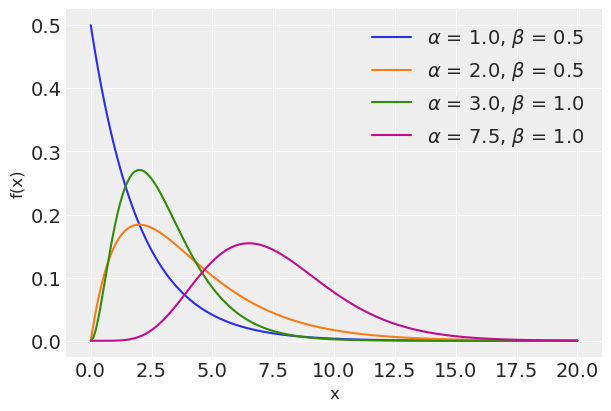

In [3]:
x = np.linspace(0, 20, 200)
alphas = [1., 2., 3., 7.5]
betas = [.5, .5, 1., 1.]
for a, b in zip(alphas, betas):
    pdf = st.gamma.pdf(x, a, scale=1.0/b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Inverse Gamma

The Inverse Gamma represents the reciprocal of a Gamma-distributed random variable, meaning that if $Y$ is Gamma distributed, then $\frac{1}{Y}$ is Inverse-Gamma distributed.

<u><i>PDF:</i></u>

$f(y;\alpha, \beta) = \frac{1}{\Gamma(\alpha)}\,\frac{\beta^\alpha}{y^{\alpha+1}} \,\mathrm{e}^{-\beta / y}$

<u><i>Expected Value:</i></u> $\displaystyle{\frac{\beta}{\alpha - 1}}, \alpha \gt 1$

<u><i>Variance:</i></u> $\displaystyle{\frac{\beta^2}{(\alpha-1)^2(\alpha-2)}}, \alpha \gt 2$

<u><i>CDF:</i></u>

$F(y;\alpha, \beta) = Q(\alpha, \beta/x)$

where $Q(\alpha, \beta/x)$ is a regularized upper incomplete gamma function.

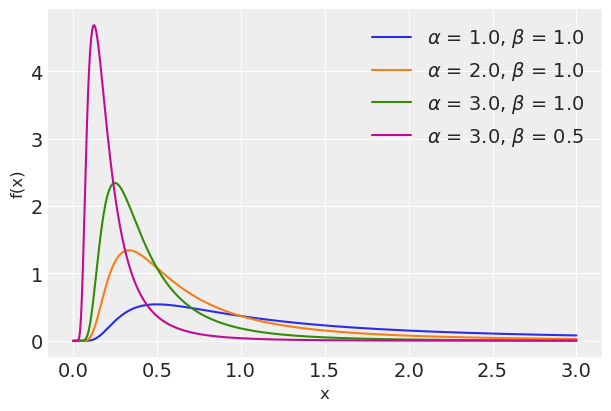

In [4]:
x = np.linspace(0, 3, 500)
alphas = [1., 2., 3., 3.]
betas = [1., 1., 1., .5]
for a, b in zip(alphas, betas):
    pdf = st.invgamma.pdf(x, a, scale=b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Weibull

The Weibull is derived from the Generalized Gamma distribution where $\delta=\beta$, and is commonly used in survival analysis. It is a generalization of the Exponential distribution, with more flexible shape.

<u><i>PDF:</i></u>

$f(y;\alpha, \sigma) = \frac{\alpha}{\sigma}\left(\frac{y}{\sigma}\right)^{\alpha - 1}\,\mathrm{e}^{-(y/\sigma)^\alpha}$

<u><i>Expected Value:</i></u> $\displaystyle{\sigma \Gamma(1 + 1/\alpha)}$

<u><i>Variance:</i></u> $\displaystyle{\sigma^2\left[\Gamma(1+2/\alpha) - \left(\Gamma(1 + 1/\alpha)\right)^2\right]}$

<u><i>CDF:</i></u>

$F(y;\alpha, \sigma) = 1 - \mathrm{e}^{-(x/\sigma)^\alpha}$

C:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:2441: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


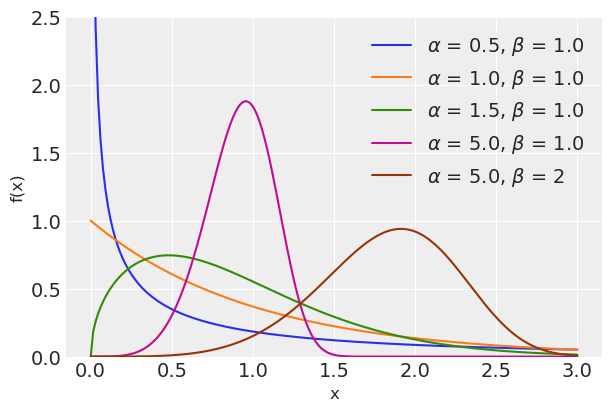

In [5]:
x = np.linspace(0, 3, 200)
alphas = [.5, 1., 1.5, 5., 5.]
betas = [1., 1., 1., 1.,  2]
for a, b in zip(alphas, betas):
    pdf = st.weibull_min.pdf(x, a, scale=b)
    plt.plot(x, pdf, label=r'$\alpha$ = {}, $\beta$ = {}'.format(a, b))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 2.5)
plt.legend(loc=1)
plt.show()

# Exponential

The Exponential distribution is a special case of the Weibull (and therefore the Gamma). It arises from the Generalized Gamma where $\delta=1$ and $\beta=1$, from the Gamma when $\alpha=1$, and from the Weibull when $k=1$.

The story is that the Exponential random variable describes the time between rare events that occur with a rate of $\beta$ per unit of time (following a Poisson process). The inter-arrival time of a Poisson process is Exponentially distributed. The single parameter is the postiive arrival rate, $\lambda$.

<u><i>PDF:</i></u>

$f(y; \lambda) = \lambda e ^{- \lambda y}$

<u><i>Expected Value:</i></u> $\frac{1}{\lambda}$

<u><i>Variance:</i></u> $\frac{1}{\lambda^2}$

<u><i>CDF:</i></u>

$F(y; \lambda) = 1 - e^{-\lambda y}$

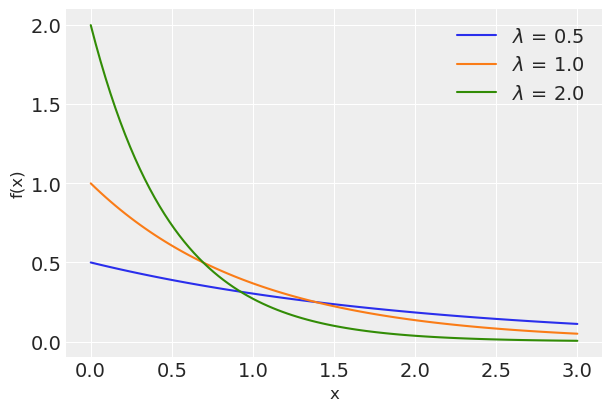

In [6]:
x = np.linspace(0, 3, 100)
for lam in [0.5, 1., 2.]:
    pdf = st.expon.pdf(x, scale=1.0/lam)
    plt.plot(x, pdf, label=r'$\lambda$ = {}'.format(lam))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc=1)
plt.show()

# Chi-Squared

The Chi-Squared distribution is a Gamma distribution with fixed shape parameter $\alpha = \frac{k}{2}$ and scale parameter $\beta=2$, where $k$ is the degrees of freedom. The Chi-Squared distribution with $k$ degrees of freedom is the distribution of the sum of squares of $k$ independent standard Normal variables. Each squared standard normal random variable $Z_i^2$ follows a Chi-Squared distribution with $1$ degree of freedom, and when you sum such distributions, the resulting distribution is $\chi^2(k)$.

<u><i>PDF:</i></u>

$f(y;k) = \frac{ y^{k/2-1} e^{-x/2} }{ 2^{k/2} \Gamma \left( \frac{k}{2} \right) }$

where $k$ is the degrees of freedom.

<u><i>Expected Value:</i></u> $k$

<u><i>Variance:</i></u> $2k$

<u><i>CDF:</i></u>

$F(y;k) = \frac{ \gamma \left( \frac{k}{2}, \frac{y}{2} \right) }{ \Gamma \left( \frac{k}{2} \right) }$

where $\gamma \left( \frac{k}{2}, \frac{y}{2} \right)$ is the lower incomplete gamma function, and $\Gamma \left( \frac{k}{2} \right)$ is the complete gamma function.

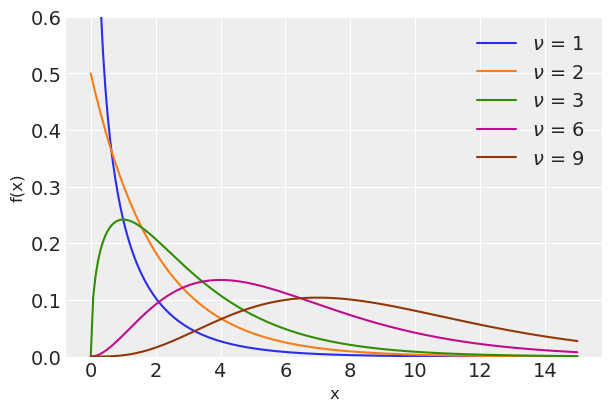

In [7]:
x = np.linspace(0, 15, 200)
for df in [1, 2, 3, 6, 9]:
    pdf = st.chi2.pdf(x, df)
    plt.plot(x, pdf, label=r'$\nu$ = {}'.format(df))
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 0.6)
plt.legend(loc=1)
plt.show()

# F-Distribution

The F-distribution arises when comparing the variances of two independent Chi-Squared distributions. 

<u><i>PDF:</i></u>

For independent Chi-Squared random variables $X_1$ and $X_2$ with $d_1$ and $d_2$ degrees of freedom respectively, it is defined as:

$F = \frac{ Y_1/d_1 }{ Y_2/d_2 }$

<u><i>CDF:</i></u>

$V(x;, d_1, d_2) = I_{\frac{ d_1 }{ d_1 + d_2 x }} \left( \frac{d_1}{2}, \frac{d_2}{2} \right)$

where $I_z(a,b)$ is the regularized incomplete beta function, and $\beta(a,b)$ is the complete beta function.

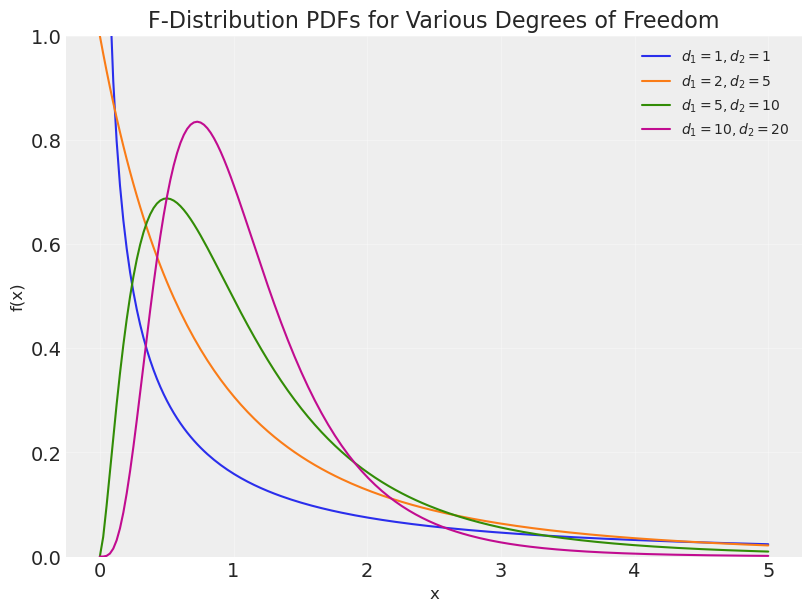

In [8]:
x = np.linspace(0, 5, 200)  # Adjust the range of x as needed for the F-distribution
d1_values = [1, 2, 5, 10]   # Degrees of freedom for the numerator
d2_values = [1, 5, 10, 20]  # Degrees of freedom for the denominator

plt.figure(figsize=(8, 6))

for d1, d2 in zip(d1_values, d2_values):
    pdf = st.f.pdf(x, d1, d2)
    plt.plot(x, pdf, label=r'$d_1 = {}, d_2 = {}$'.format(d1, d2))

plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.ylim(0, 1.0)  # Adjust based on the observed range of the F-distribution
plt.title('F-Distribution PDFs for Various Degrees of Freedom')
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

# References

- ...
- ...